In [1]:
import pandas as pd  

In [2]:
df = pd.read_csv(r"C:\Users\Riya Thokal\Downloads\Car_sales.csv")

In [3]:
df

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

# Funnel Chart

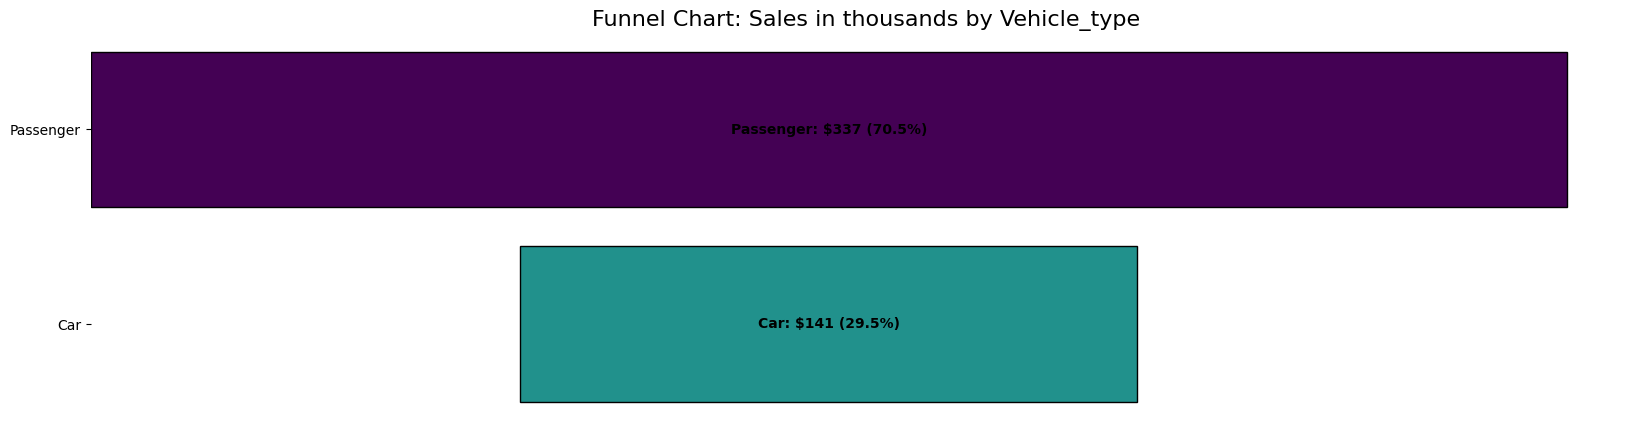

In [6]:
funnel_data = df.groupby('Vehicle_type')['Engine_size'].sum().sort_values(ascending=False).reset_index()
labels = funnel_data['Vehicle_type']
values = funnel_data['Engine_size']

# Calculate percentages for labeling
total_sales = values.sum()
percent_values = (values / values.iloc[0]) * 100 # Percentage of first stage

# --- Plotting ---
fig, ax = plt.subplots(figsize=(20,5))

# Plot bars, centering them by shifting start points
for i in range(len(labels)):
    width = values[i]
    # Center the bar
    offset = (max(values) - width) / 2
    ax.barh(labels[i], width, left=offset, color=plt.cm.viridis(i/len(labels)), edgecolor='black')
    
    # Add data labels
    ax.text(max(values)/2, i, f'{labels[i]}: ${width:,.0f} ({width/total_sales:.1%})', 
            ha='center', va='center', color='black', fontweight='bold', fontsize=10)

# Aesthetics
ax.set_title('Funnel Chart: Sales in thousands by Vehicle_type', fontsize=16)
ax.set_xticks([]) # Remove x-axis
ax.invert_yaxis() # Highest value at the top
plt.box(False) # Remove border

plt.show()

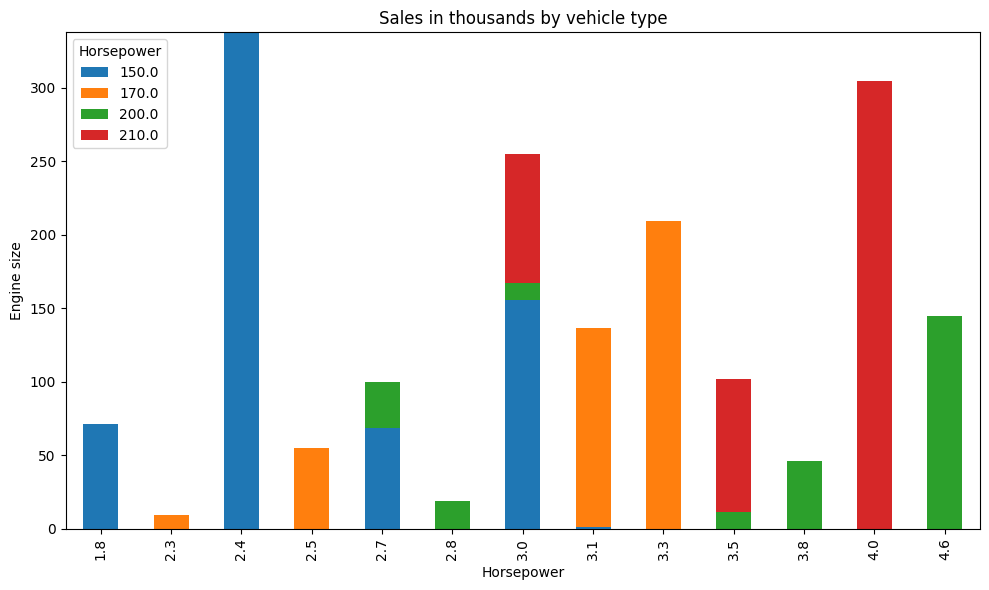

In [7]:
top_hp = df['Horsepower'].value_counts().head(4).index

# Filter dataset
filtered_df = df[df['Horsepower'].isin(top_hp)]

# Group and plot
grouped_data = filtered_df.groupby(['Engine_size', 'Horsepower'])['Sales_in_thousands'].sum().unstack()

grouped_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Sales in thousands by vehicle type')
plt.ylabel('Engine size')
plt.xlabel('Horsepower')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

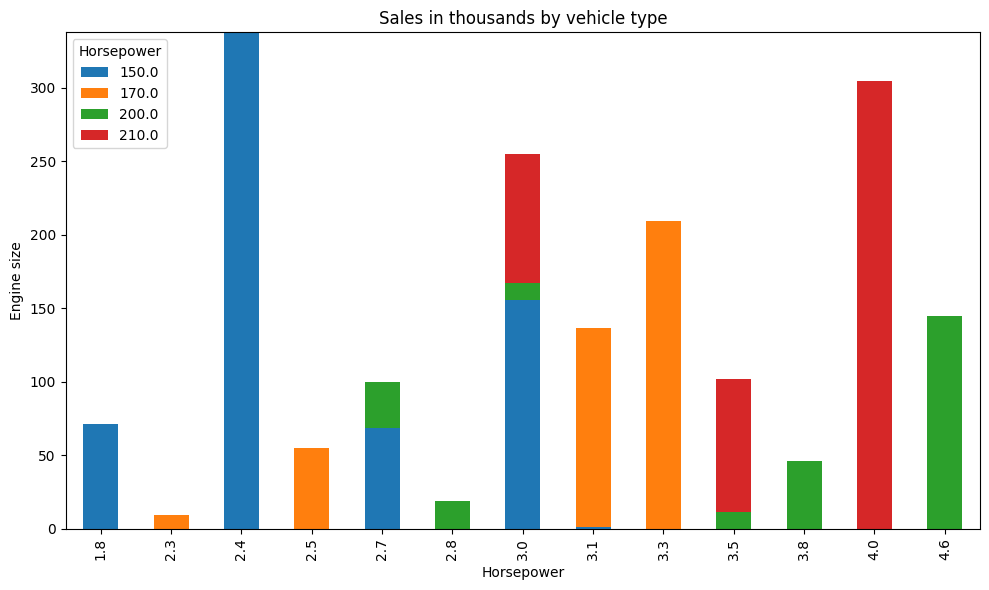

In [8]:
top_hp = df['Horsepower'].value_counts().head(6).index

# Filter dataset
top_hp = df['Horsepower'].value_counts().head(6).index

# Group and plot
grouped_data = filtered_df.groupby(['Engine_size', 'Horsepower'])['Sales_in_thousands'].sum().unstack()

grouped_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Sales in thousands by vehicle type')
plt.ylabel('Engine size')
plt.xlabel('Horsepower')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

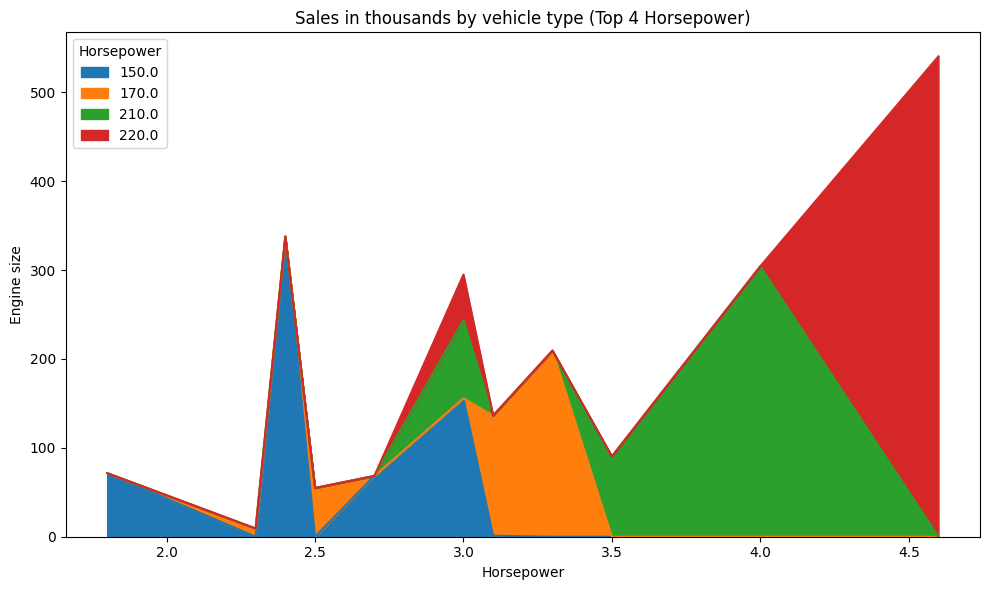

In [9]:


# Get top 4 horsepower values based on total sales
top_hp = (
    df.groupby('Horsepower')['Sales_in_thousands']
    .sum()
    .nlargest(4)
    .index
)

# Filter dataset
filtered_df = df[df['Horsepower'].isin(top_hp)]

# Group again
grouped_data = (
    filtered_df.groupby(['Engine_size', 'Horsepower'])['Sales_in_thousands']
    .sum()
    .unstack()
)

# Plot
grouped_data.plot(kind='area', stacked=True, figsize=(10,6))

plt.title('Sales in thousands by vehicle type (Top 4 Horsepower)')
plt.ylabel('Engine size')
plt.xlabel('Horsepower')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()